最佳特征数量: 69

==== 开始嵌套交叉验证 ====
Fold 1 AUC: 0.8888
Fold 2 AUC: 0.8113
Fold 3 AUC: 0.8092
Fold 4 AUC: 0.7432
Fold 5 AUC: 0.7298

==== 嵌套CV结果 ====
平均AUC: 0.7965 ± 0.0569


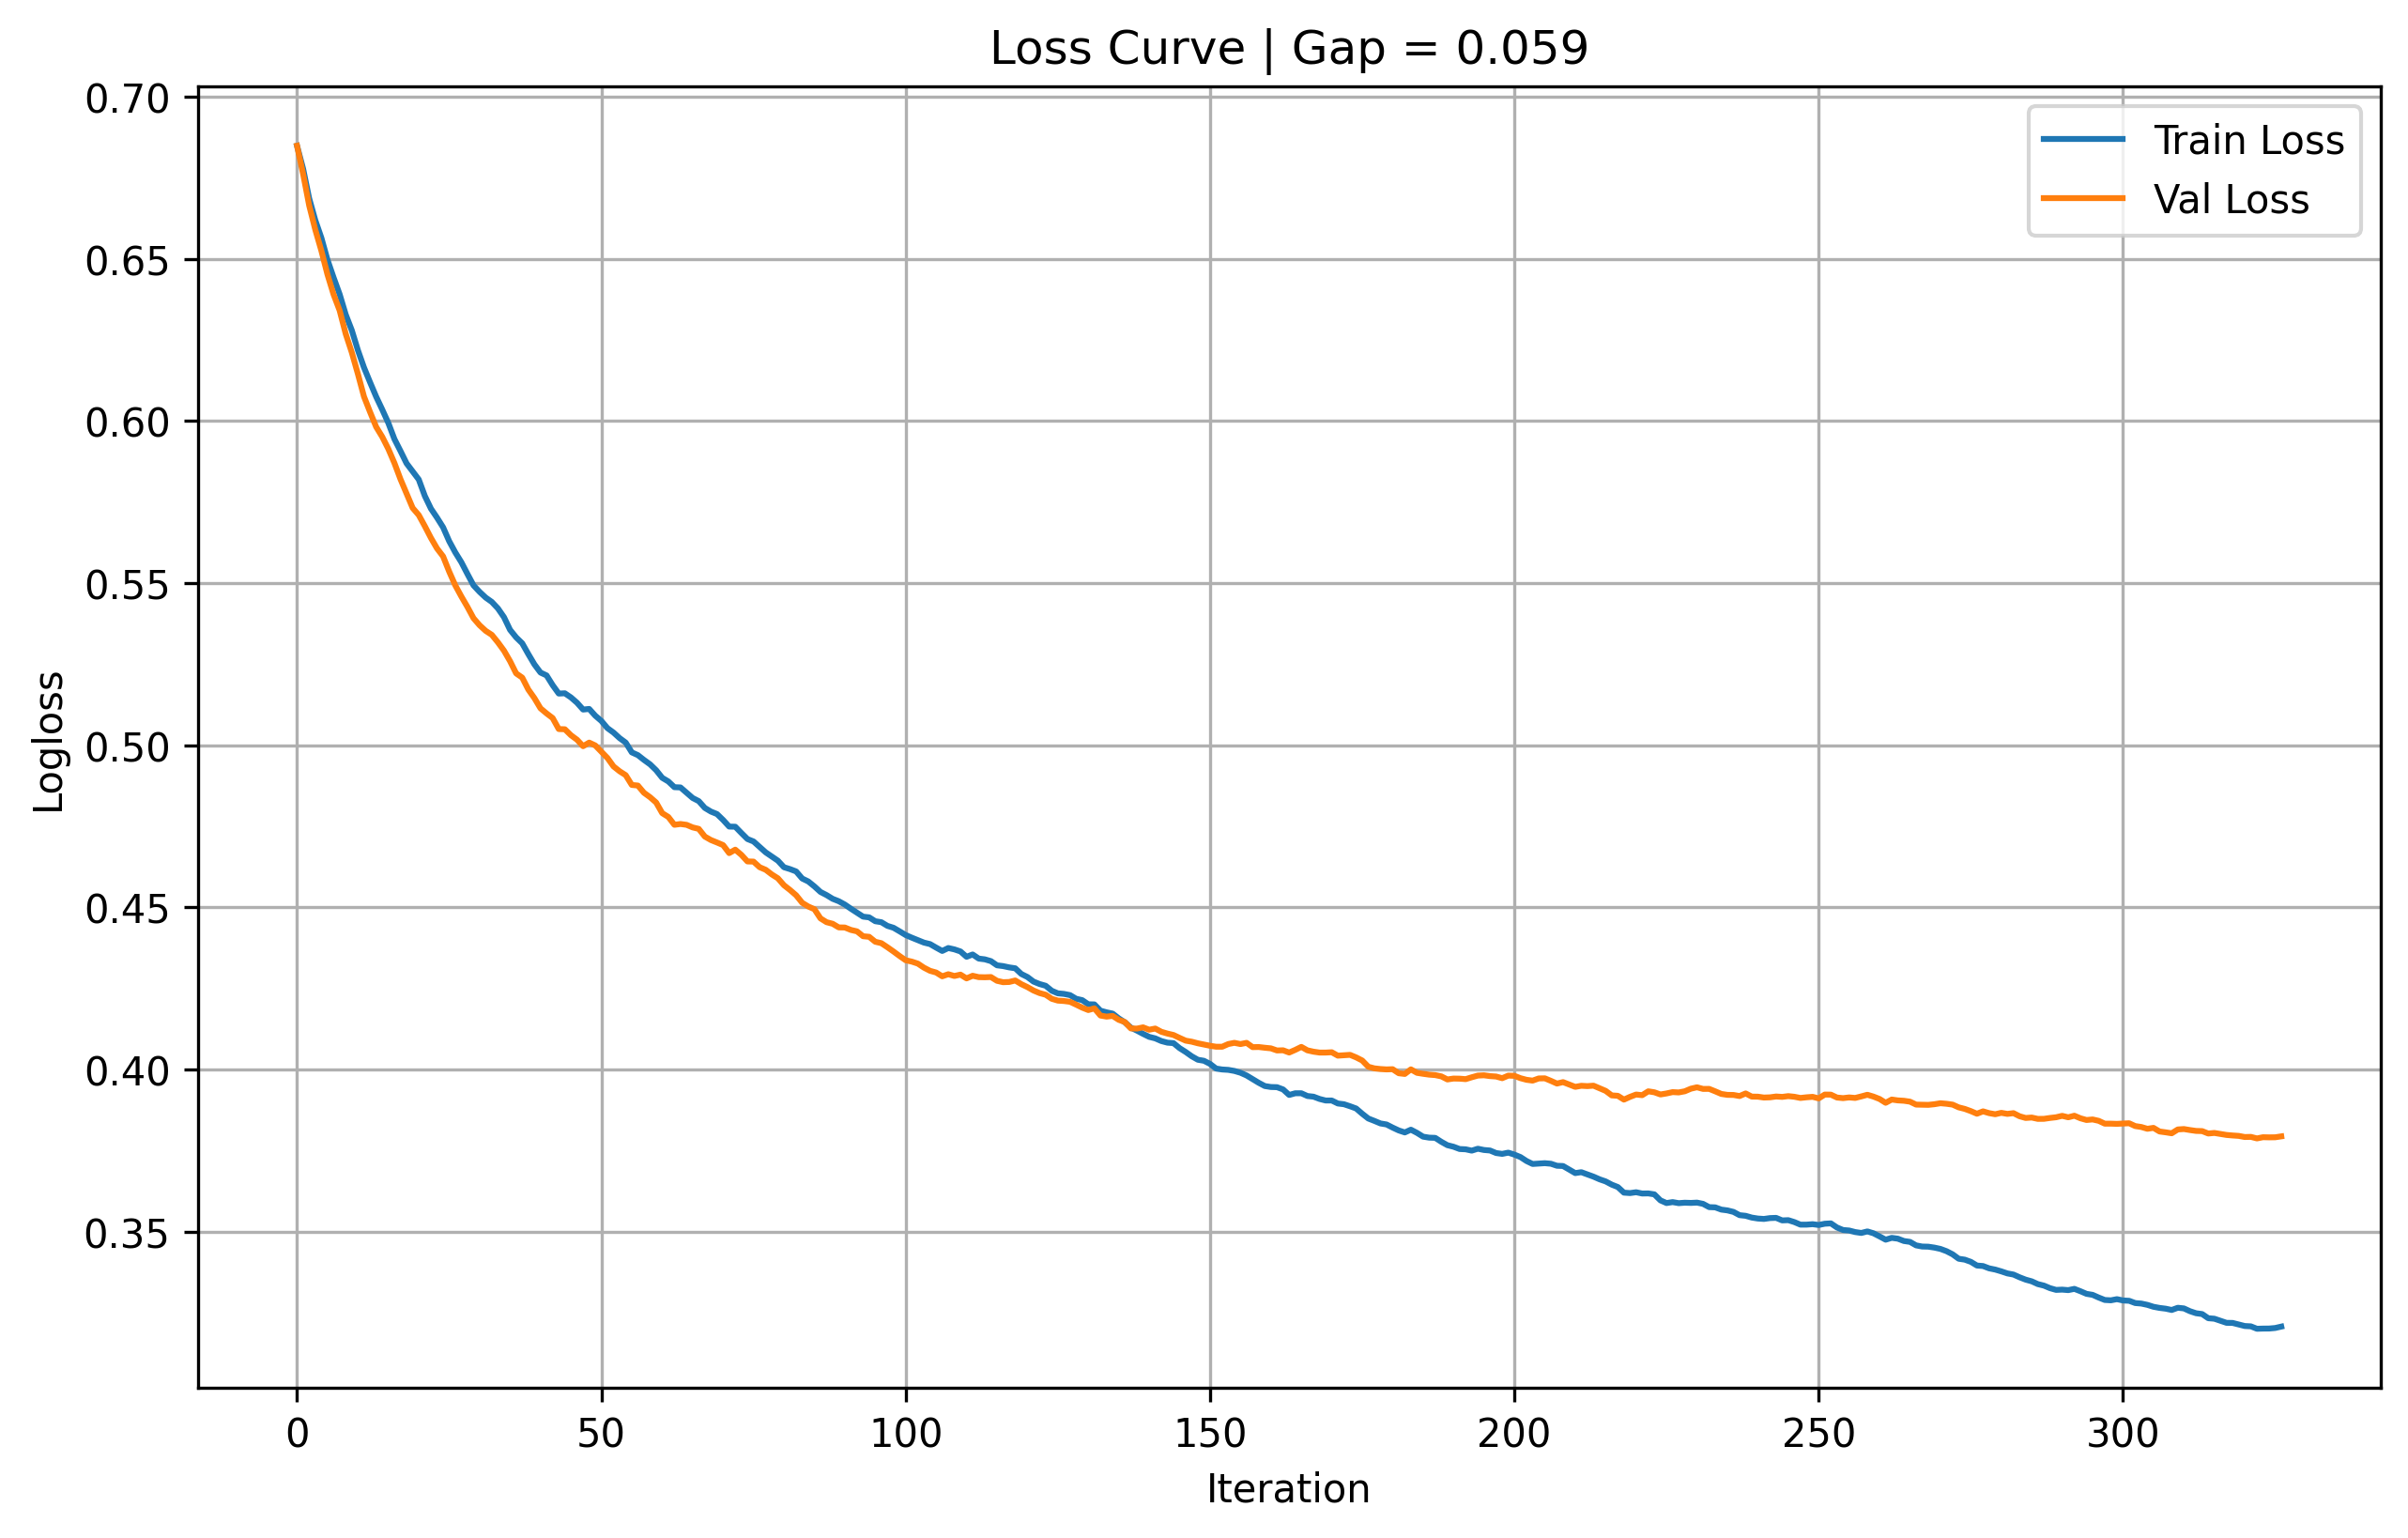


==== 测试集最优模型指标 ====
Accuracy: 0.6948
Precision: 0.4222
Recall: 0.4750
F1: 0.4471
AUC: 0.6700
Loss Gap: 0.0587


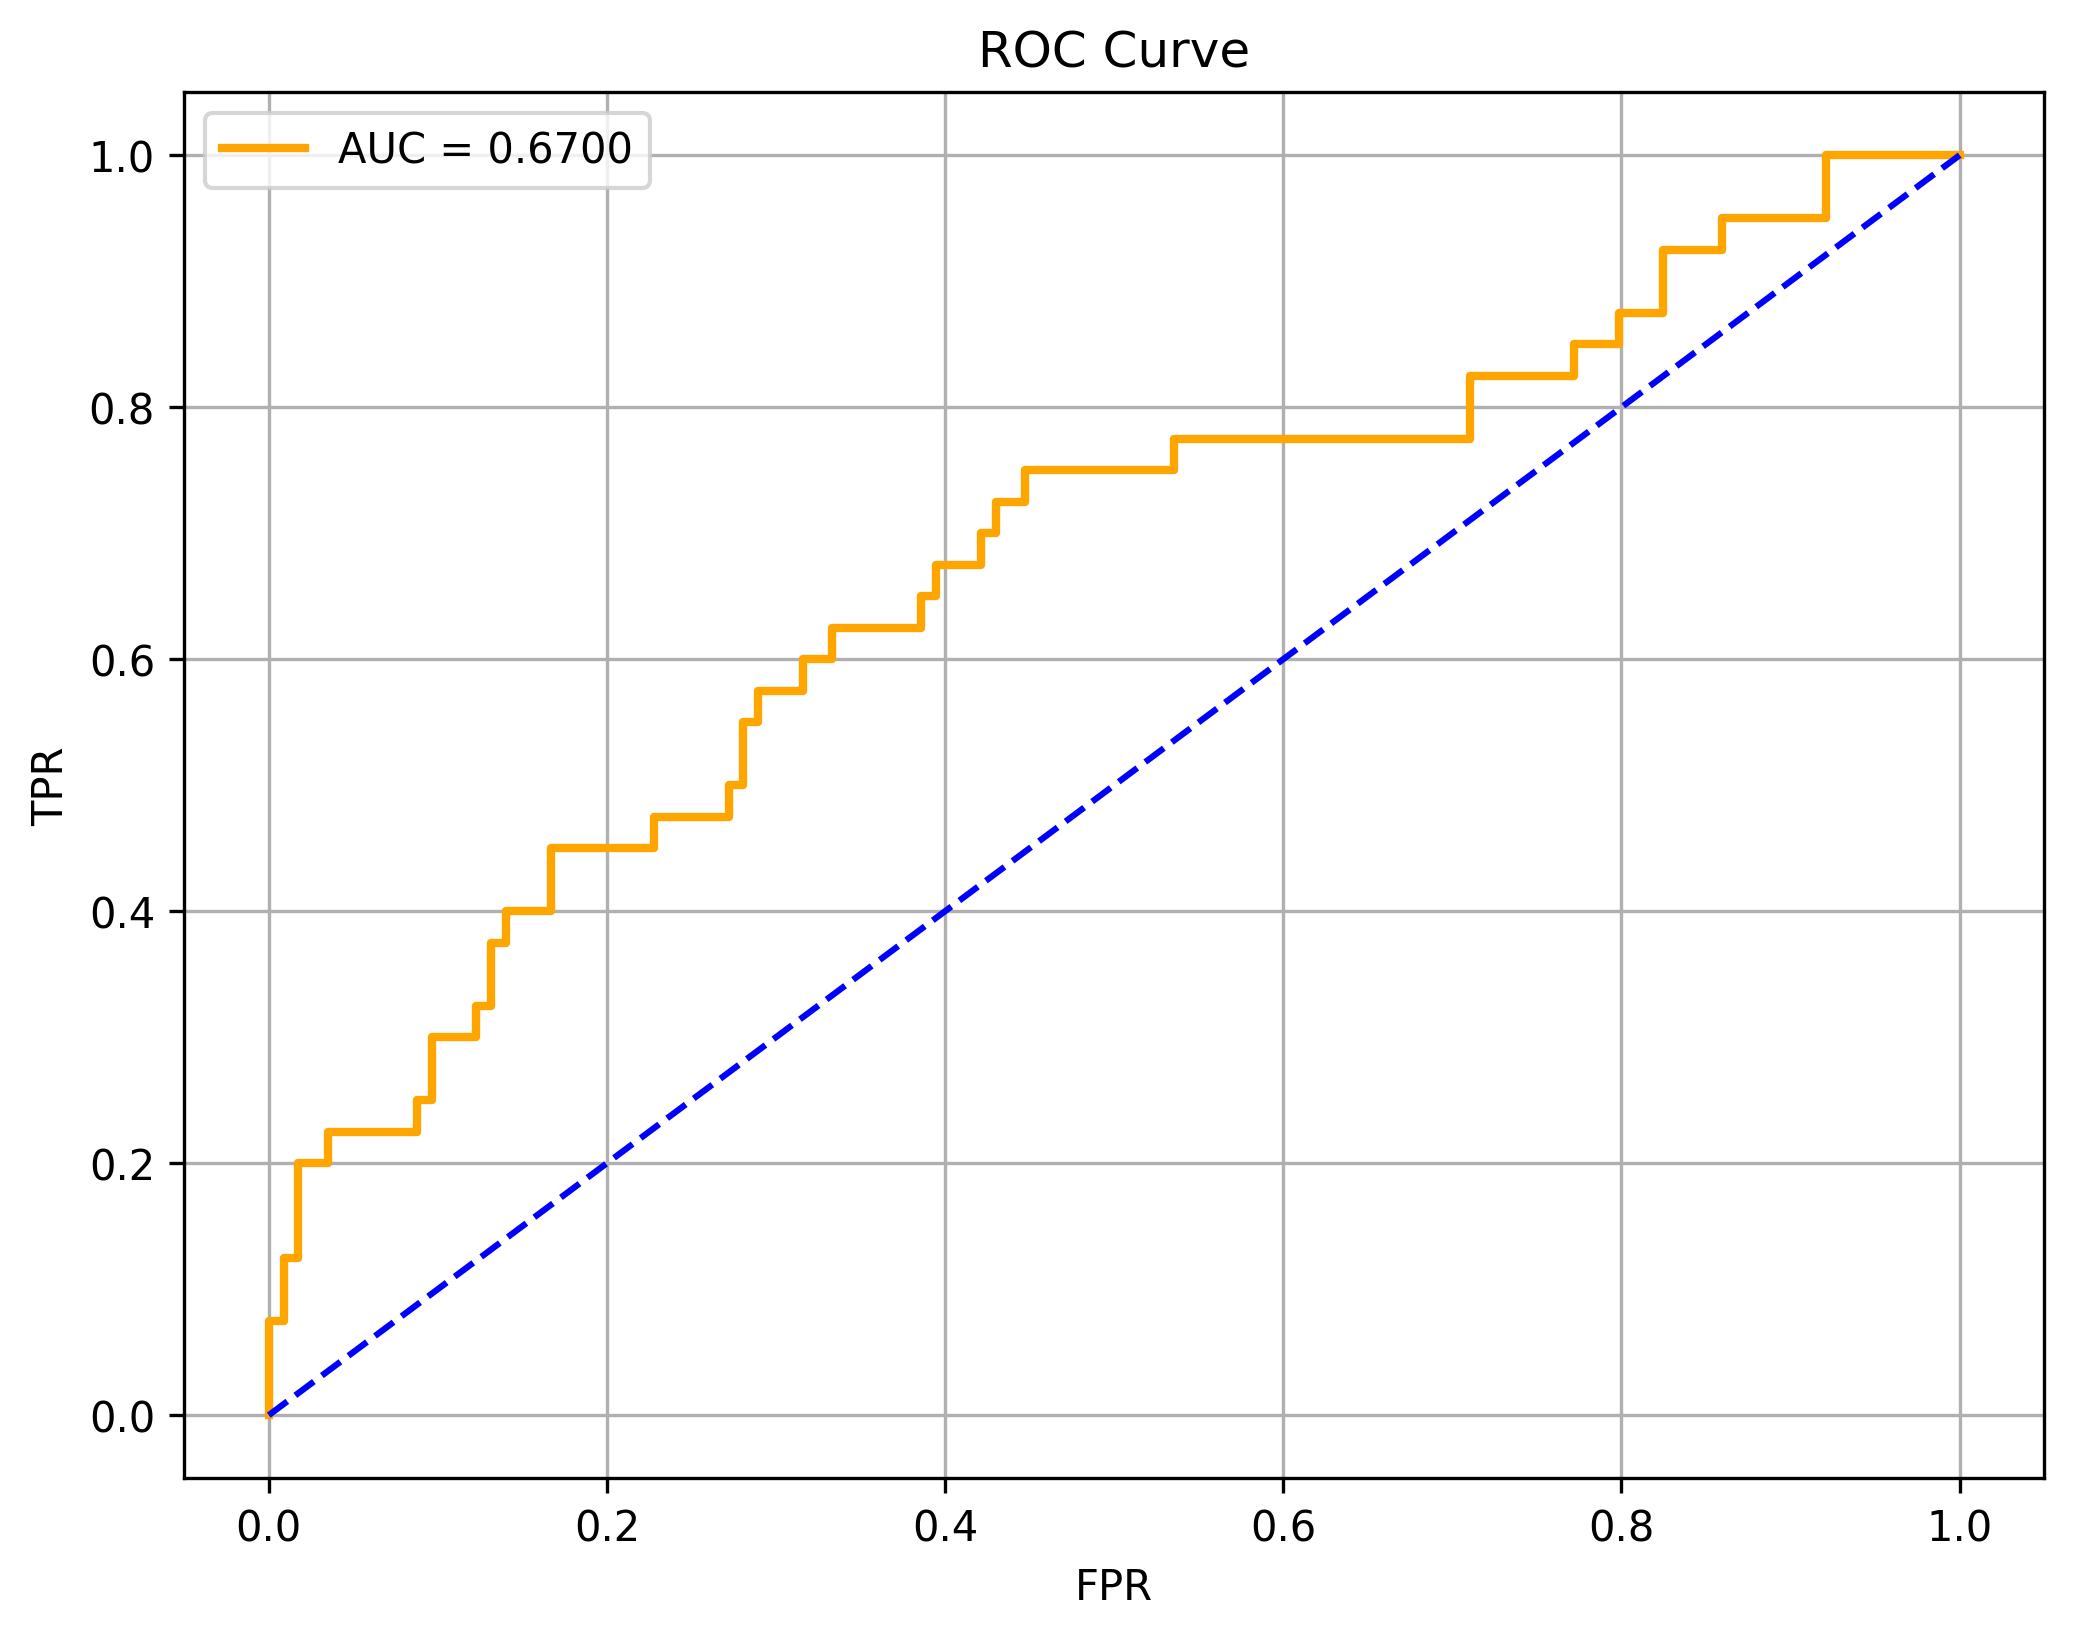

In [1]:
# ================================
# XGBoost 
# ================================
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. 加载数据
CSV_PATH = r"/root/molecular_descriptorsAML9.6-checkpoint.csv"
df = pd.read_csv(CSV_PATH)
df1 = df.drop(columns="SMILES")
mask = df1.apply(lambda col: col.map(lambda x: x == ''))
df2 = df1[~mask.any(axis=1)].reset_index(drop=True)

mapping = {"active": 1, "Inactive": 0}
df2["Activity2"] = df2["Activity"].map(mapping).fillna(0)
df2 = df2.drop(columns="Activity")

data = np.array(df2)
X = data[:, :-1].astype(float)
y = data[:, -1].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

# ================================
# 2. 特征选择
# ================================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='roc_auc', min_features_to_select=5, n_jobs=-1)
rfecv.fit(X_train, y_train)

X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)
print(f"最佳特征数量: {rfecv.n_features_}")

# ================================
# 3. 嵌套交叉验证
# ================================
param_grid = {
    'max_depth': [2],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.5, 0.6],
    'colsample_bytree': [0.5, 0.6],
    'reg_alpha': [2.0, 3.0],
    'reg_lambda': [4.0, 5.0],
    'min_child_weight': [5, 7]
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_scores = []
best_models = []

print("\n==== 开始嵌套交叉验证 ====")
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_selected, y_train), 1):
    X_tr, X_val = X_train_selected[train_idx], X_train_selected[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    grid = GridSearchCV(
        estimator=xgb.XGBClassifier(
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            random_state=42, n_jobs=-1
        ),
        param_grid=param_grid,
        cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid.fit(X_tr, y_tr)
    
    val_pred = grid.best_estimator_.predict_proba(X_val)[:,1]
    val_auc = roc_auc_score(y_val, val_pred)
    outer_scores.append(val_auc)
    best_models.append(grid.best_estimator_)
    print(f"Fold {fold} AUC: {val_auc:.4f}")

best_idx = np.argmax(outer_scores)
best_model = best_models[best_idx]
mean_auc = np.mean(outer_scores)
std_auc = np.std(outer_scores)

print(f"\n==== 嵌套CV结果 ====")
print(f"平均AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# ================================
# 4. 绘制学习曲线（完全修复报错）
# ================================
X_train_part, X_val_early, y_train_part, y_val_early = train_test_split(
    X_train_selected, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 直接使用最优模型，不重复传参
curve_model = xgb.XGBClassifier(**best_model.get_params())
curve_model.set_params(
    n_estimators=2000,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

curve_model.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val_early, y_val_early)],
    verbose=False
)

# 绘图
plot_model = xgb.XGBClassifier(**best_model.get_params())
plot_model.set_params(
    n_estimators=curve_model.best_iteration,
    eval_metric='logloss'
)

plot_model.fit(
    X_train_part, y_train_part,
    eval_set=[(X_train_part, y_train_part), (X_val_early, y_val_early)],
    verbose=False
)

res = plot_model.evals_result()
tr_loss = res['validation_0']['logloss']
va_loss = res['validation_1']['logloss']
gap = va_loss[-1] - tr_loss[-1]

plt.figure(figsize=(10,6), dpi=300)
plt.plot(tr_loss, label='Train Loss')
plt.plot(va_loss, label='Val Loss')
plt.title(f'Loss Curve | Gap = {gap:.3f}')
plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()

# ================================
# 5. 测试集评估 + ROC 曲线
# ================================
y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n==== 测试集最优模型指标 ====")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Loss Gap: {gap:.4f}")

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6), dpi=300)
plt.plot(fpr, tpr, 'orange', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], 'b--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()